# Fenêtres

In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
plt.style.use('../../src/signal.mplstyle')

<>:59: SyntaxWarning: invalid escape sequence '\l'
<>:59: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_11810/1286077906.py:59: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$20 \log_{10}(|H(f)|)$')


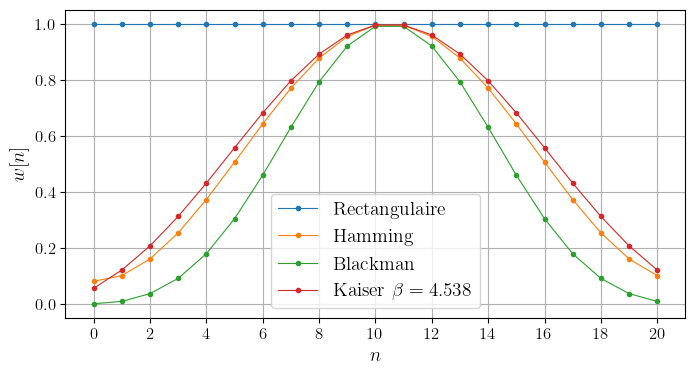

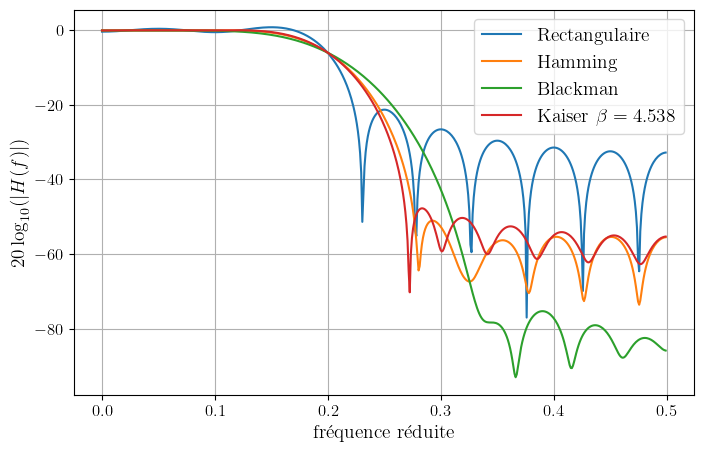

In [2]:
# Paramètres
fc = 0.2
fe = 1
N = 20
L = N+1

# Fenêtres possibles
windows = {
    "rect"     : (('boxcar')        , 0.90/N, 0.742,    21,     0.24  , "Rectangulaire"),
    "hamming"  : (('hamming')       , 3.30/N, 0.019,    53,     0.2   , "Hamming"      ),
    "blackman" : (('blackman')      , 5.50/N, 0.002,    74,     np.nan, "Blackman"),
    "kaiserA"  : (('kaiser', 4.538) , 2.93/N, 0.0274,   50,     np.nan, "Kaiser $\\beta=4.538$"),
    # "kaiserB"  : (('kaiser', 6.764) , 4.32/N, 0.00275,  70,     np.nan),
    # "kaiserC"  : (('kaiser', 8.960) , 5.71/N, 0.000275, 90,     np.nan),
    # "kaiser3"  : (('kaiser', 3)     , np.nan, np.nan,   np.nan, np.nan),
    # "kaiser4"  : (('kaiser', 4)     , np.nan, np.nan,   np.nan, np.nan),
    # "kaiser5"  : (('kaiser', 5)     , np.nan, np.nan,   np.nan, np.nan),
    # "kaiser6"  : (('kaiser', 6)     , np.nan, np.nan,   np.nan, np.nan),
    # "kaiser7"  : (('kaiser', 7)     , np.nan, np.nan,   np.nan, np.nan),
}

# Réponse impulsionnelle
n = np.arange(L) - np.floor(L/2)
ho = 2*fc*np.sinc(2*fc*n)

# Préparation de l'affichage
fig1, ax1 = plt.subplots(1, 1, figsize=(8,4))
fig2, ax2 = plt.subplots(1, 1, figsize=(8,5))

for windows, params in windows.items():

    # Fenêtrage
    w = signal.get_window(window=params[0], Nx=L)
    h = ho * w

    # Réponse fréquentielle
    f, H = signal.freqz(b=h, a=1, fs=fe)

    # Fenêtre
    ax1.plot(w, '.-', linewidth=.8, label=params[5])
    ax1.set_xticks(np.arange(0,L,2))
    
    # Réponse fréquentielle du filtre passe-bas
    ax2.plot(f, 20*np.log10(abs(H)), label=params[5])
    # ax2.axhline(-win[2],color='k',linewidth=.8)
    # ax2.axhline(-win[3],color='k',linewidth=.8)
    # ax2.axvline(win[4],color='k',linewidth=.8)
    # ax2.axvline(win[4]+win[1],color='k',linewidth=.8)

plt.figure(fig1)
plt.legend()
plt.xlabel('$n$')
plt.ylabel('$w[n]$')
plt.savefig("rif-windows.svg")
plt.savefig("rif-windows.png")
plt.figure(fig2)
plt.legend()
plt.xlabel('fréquence réduite')
plt.ylabel('$20 \log_{10}(|H(f)|)$')
plt.savefig("rif-window-method.svg")
plt.savefig("rif-window-method.png")

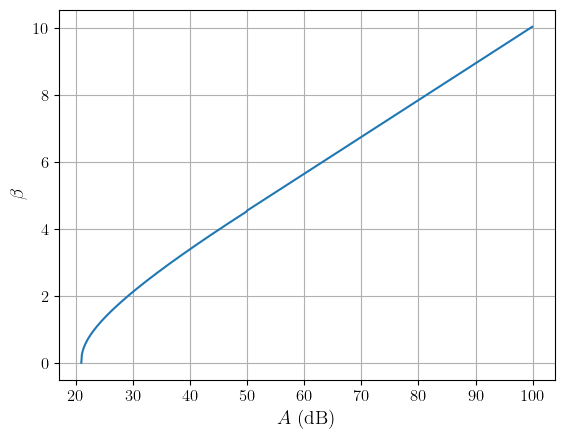

In [3]:
def beta(A):
    # Oppenheim, Discrete-Time Signal Processing, Pearson, Eq (45) in chapter 7
    # cf aussi scipy.signal.kaiser_beta
    Ac = np.array(A, dtype=np.complex128)
    b1 = np.where(  A>50,               0.1102*(A-8.7),                      0.0)
    b2 = np.where( (A>=21) & (A<=50), 0.5842*(Ac-21)**.4 + 0.07886*(A-21), 0.0)
    b3 = np.where(  A<21,               0.0,                                 0.0)
    b = np.real(b1 + b2 + b3)
    return b

A = np.arange(21,100,.1)
plt.figure()
plt.plot(A, beta(A))
plt.xlabel('$A$ (dB)')
plt.ylabel(r'$\beta$')
plt.show()


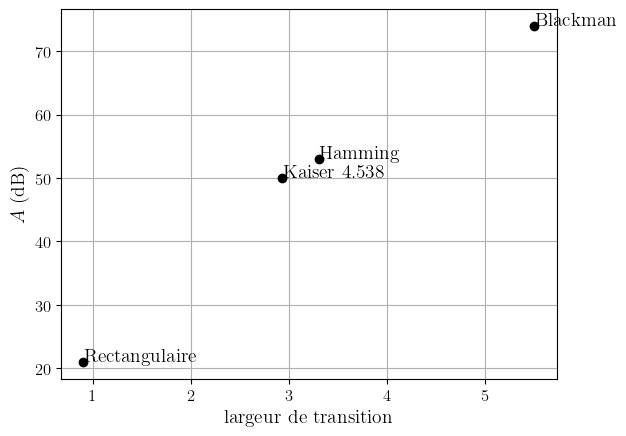

In [4]:
# Oppenheim, Discrete-Time Signal Processing, Pearon, p.566

def toto(x,y,text):
    plt.plot(x, y, 'ko')
    plt.annotate(text, (x+.002,y+.1))


plt.figure()

toto(0.9, 21, "Rectangulaire")
toto(3.3, 53, "Hamming")
toto(5.5, 74, "Blackman")
toto(2.93, 50, "Kaiser 4.538")

plt.xlabel('largeur de transition')
plt.ylabel('$A$ (dB)')

plt.show()

In [5]:
def beta(A):
    # Oppenheim, Discrete-Time Signal Processing, Pearson, Eq (45) in chapter 7
    # cf aussi scipy.signal.kaiser_beta
    Ac = np.array(A, dtype=np.complex128)
    b1 = np.where(  A>50,               0.1102*(A-8.7),                      0.0)
    b2 = np.where( (A>=21) & (A<=50), 0.5842*(Ac-21)**.4 + 0.07886*(A-21), 0.0)
    b3 = np.where(  A<21,               0.0,                                 0.0)
    b = np.real(b1 + b2 + b3)
    return b
    
frN = 5.71
A = 4.57*np.pi*frN + 8
print(A)
print(beta(A))

89.97891781762958
8.95693674350278
